# Análisis Comparativo Longitudinal — ENSADUL / ENSANUT Guanajuato 2020–2022
## Tendencias en salud del adulto

> Este notebook une los datasets limpios de los tres años y compara las variables
> disponibles en cada encuesta. Dado que la edición 2020 fue una encuesta COVID-19
> con un cuestionario diferente, las comparaciones se organizan en dos grupos:
>
> - **Tres años (2020–2022):** tabaco, alcohol, ideación suicida, violencia, demografía
> - **Dos años (2021–2022):** enfermedades crónicas, score de síntomas depresivos, discapacidades

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('future.no_silent_downcasting', True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

COLORS = {'2020':'#E06C75', '2021':'#61AFEF', '2022':'#98C379'}
YEARS  = ['2020', '2021', '2022']

---
## 1. Carga y armonización de datasets

In [2]:
df20 = pd.read_csv('../data/processed/ensanut2020_GTO_clean.csv')
df21 = pd.read_csv('../data/processed/ensadul2021_GTO_clean.csv')
df22 = pd.read_csv('../data/processed/ensadul2022_GTO_clean.csv')

print(f'2020: {df20.shape}  |  2021: {df21.shape}  |  2022: {df22.shape}')

2020: (1035, 28)  |  2021: (1115, 79)  |  2022: (1227, 66)


In [3]:
# ── Normalizar columnas clave a nombres comunes ──────────────────────────────

for df, yr in [(df20,'2020'),(df21,'2021'),(df22,'2022')]:
    df['año'] = int(yr)

    # Edad
    if 'Edad del Seleccionado' in df.columns:
        df['edad'] = df['Edad del Seleccionado']
    elif 'Edad' in df.columns:
        df['edad'] = df['Edad']

    # Sexo → 1=Hombre, 2=Mujer
    if 'Sexo del Seleccionado' in df.columns:
        df['sexo'] = df['Sexo del Seleccionado']
    elif 'Sexo' in df.columns:
        df['sexo'] = df['Sexo']
    df['sexo_lbl'] = df['sexo'].map({1:'Hombre', 2:'Mujer'})

    # Tabaco actual → 1=fuma diario, 2=fuma ocasional, 3=no fuma, 9=ns
    if yr == '2020':
        df['tabaco_actual'] = df['ADUL1a01 Actualmente fuma tabaco...']
    else:
        df['tabaco_actual'] = df['A1301 Actualmente, ¿fuma tabaco…']
    df['fuma'] = df['tabaco_actual'].isin([1,2]).astype(int)

    # Alcohol → binario: consume (1,2,3,4) vs no (5,6,9)
    if yr == '2020':
        alc_col = 'ADUL1a06 Piensa en tu consumo de alcohol, ¿con qué frecuencia tomas una copa de ya sea vino, cerveza, whisky o cualquier otra bebida que contenga alcohol?'
    else:
        alc_col = [c for c in df.columns if 'A1308' in c][0]
    df['consume_alcohol'] = df[alc_col].isin([1,2,3,4]).astype(int)
    df['alcohol_frecuencia'] = df[alc_col]

    # Ideación suicida → 1=sí, 0=no
    if yr == '2020':
        suc_col = 'ADUL208 2.8 ¿Alguna vez ha pensado en suicidarse?'
    else:
        suc_col = 'A1211 ¿Alguna vez ha pensado en suicidarse?'
    df['ideacion_suicida'] = (df[suc_col] == 1).astype(int)

    # Violencia/robo en 12 meses → 1=sí, 0=no
    if yr == '2020':
        viol_col = 'ADUL201 2.1  En los últimos 12 meses ¿Sufrió usted algún daño a su salud por robo, agresión o violencia?'
    elif yr == '2021':
        viol_col = [c for c in df.columns if 'A1201' in c][0]
    else:
        viol_col = 'A1201 En los últimos 12 meses, ¿sufrió usted algun daño a su salud por robo, agresión o violencia?'
    df['victima_violencia'] = (df[viol_col] == 1).astype(int)

print('Columnas armonizadas: año, edad, sexo, sexo_lbl, tabaco_actual, fuma,')
print('                      consume_alcohol, alcohol_frecuencia, ideacion_suicida, victima_violencia')

Columnas armonizadas: año, edad, sexo, sexo_lbl, tabaco_actual, fuma,
                      consume_alcohol, alcohol_frecuencia, ideacion_suicida, victima_violencia


In [4]:
# ── Columnas solo disponibles en 2021–2022 ───────────────────────────────────

for df, yr in [(df21,'2021'),(df22,'2022')]:
    # Enfermedades crónicas: 1=Sí, 3=No (2=No sé, raro) → binario
    diab = '¿Algún médico le ha dicho que tiene diabetes (o alta el azúcar en la sangre)?'
    hta  = '¿Algún médico le ha dicho que tiene la presión alta?'
    col  = '¿Algún médico le ha dicho que tiene el colesterol alto?'
    trig = '¿Algún médico le ha dicho que tiene los triglicéridos  altos?'

    df['diabetes']      = (df[diab] == 1).astype(int)
    df['hipertension']  = (df[hta]  == 1).astype(int)
    df['colesterol']    = (df[col]  == 1).astype(int)
    df['trigliceridos'] = (df[trig] == 1).astype(int)

    # Score depresión (CES-D 7 items, rango 7-28)
    df['score_dep'] = df['Score depresión']

print('Columnas crónicas y depresión listas para 2021 y 2022.')

Columnas crónicas y depresión listas para 2021 y 2022.


In [5]:
# ── Tabla resumen de los tres datasets ───────────────────────────────────────

resumen = []
for df, yr in [(df20,'2020'),(df21,'2021'),(df22,'2022')]:
    row = {
        'Año': yr,
        'Encuesta': 'ENSANUT COVID-19' if yr=='2020' else 'ENSADUL',
        'n': len(df),
        'Edad media': round(df['edad'].mean(), 1),
        'DE edad': round(df['edad'].std(), 1),
        '% Mujeres': round((df['sexo']==2).mean()*100, 1),
        '% Urbano': round((df['Urbanidad']=='Urbano').mean()*100, 1),
        '% Fuma': round(df['fuma'].mean()*100, 1),
        '% Consume alcohol': round(df['consume_alcohol'].mean()*100, 1),
        '% Ideación suicida': round(df['ideacion_suicida'].mean()*100, 1),
        '% Víctima violencia': round(df['victima_violencia'].mean()*100, 1),
    }
    resumen.append(row)

resumen_df = pd.DataFrame(resumen).set_index('Año')
display(resumen_df)

,Encuesta,n,Edad media,DE edad,% Mujeres,% Urbano,% Fuma,% Consume alcohol,% Ideación suicida,% Víctima violencia
Año,,,,,,,,,,
2020,ENSANUT COVID-19,1035,45.8,17.9,59.0,40.1,15.5,40.7,0.0,3.3
2021,ENSADUL,1115,46.2,17.4,63.6,39.4,17.1,46.0,8.9,3.3
2022,ENSADUL,1227,46.5,17.1,65.0,37.2,15.1,46.9,6.8,2.3


---
## 2. Perfil demográfico comparado

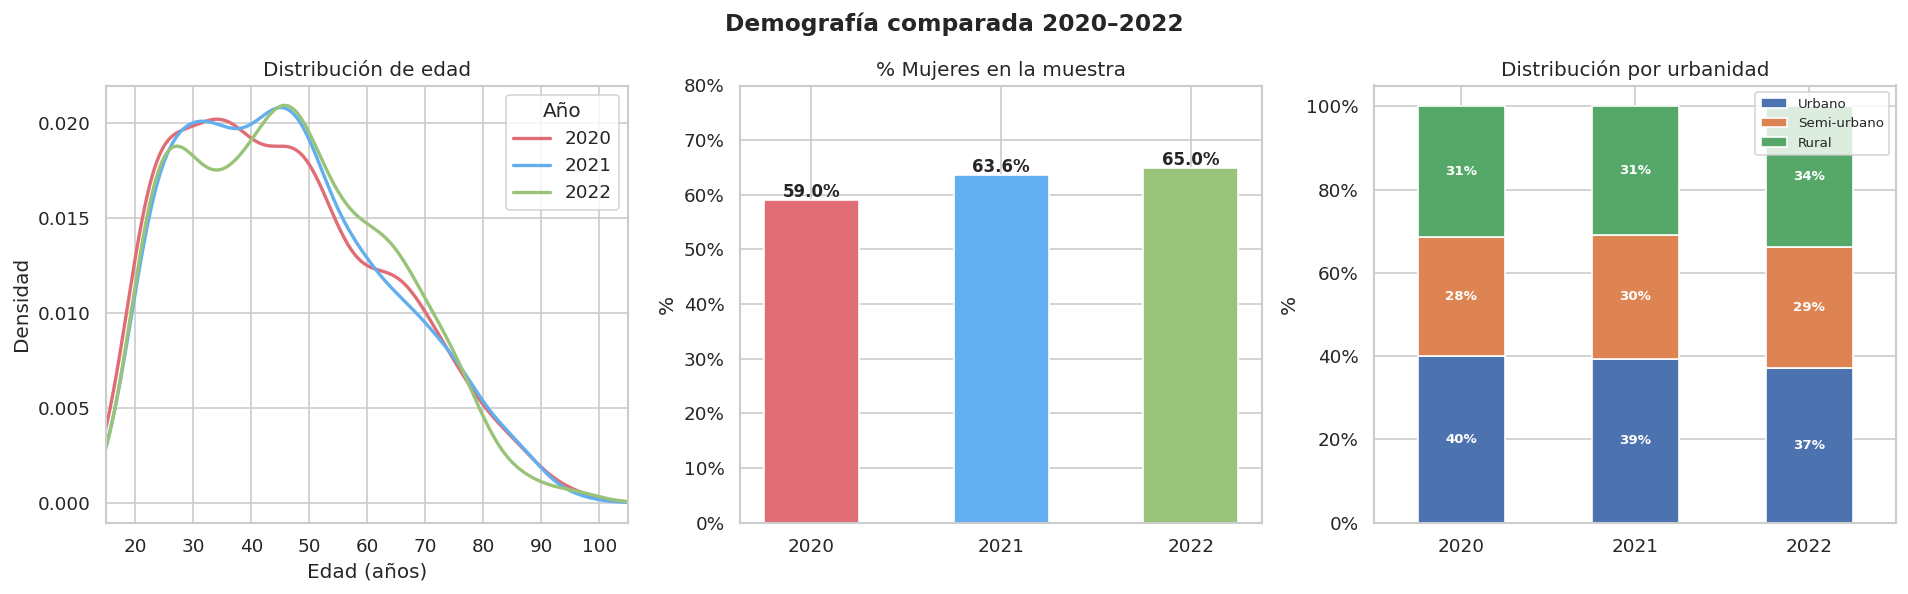

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Demografía comparada 2020–2022', fontsize=14, fontweight='bold')

# 2.1 Distribución de edad por año (KDE)
ax = axes[0]
for yr, df in [('2020',df20),('2021',df21),('2022',df22)]:
    df['edad'].plot.kde(ax=ax, label=yr, color=COLORS[yr], linewidth=2)
ax.set_title('Distribución de edad')
ax.set_xlabel('Edad (años)'); ax.set_ylabel('Densidad')
ax.legend(title='Año'); ax.set_xlim(15, 105)

# 2.2 % Mujeres por año
ax = axes[1]
pct_mujer = {yr: (df['sexo']==2).mean()*100
             for yr, df in [('2020',df20),('2021',df21),('2022',df22)]}
bars = ax.bar(pct_mujer.keys(), pct_mujer.values(),
              color=[COLORS[y] for y in pct_mujer], edgecolor='white', width=0.5)
ax.set_title('% Mujeres en la muestra')
ax.set_ylabel('%'); ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, pct_mujer.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2.3 Urbanidad por año (stacked)
ax = axes[2]
urb_data = {}
for yr, df in [('2020',df20),('2021',df21),('2022',df22)]:
    urb_data[yr] = df['Urbanidad'].value_counts(normalize=True).mul(100)
urb_df = pd.DataFrame(urb_data).T[['Urbano','Semi-urbano','Rural']]
urb_df.plot(kind='bar', stacked=True, ax=ax,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='white', width=0.5)
ax.set_title('Distribución por urbanidad')
ax.set_ylabel('%'); ax.set_xlabel('')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper right', fontsize=8)
for yr_idx, yr in enumerate(['2020','2021','2022']):
    cumsum = 0
    for cat in ['Urbano','Semi-urbano','Rural']:
        val = urb_df.loc[yr, cat]
        ax.text(yr_idx, cumsum + val/2, f'{val:.0f}%',
                ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        cumsum += val

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/demografia_comparada.png', bbox_inches='tight')
plt.show()

---
## 3. Tabaco y alcohol

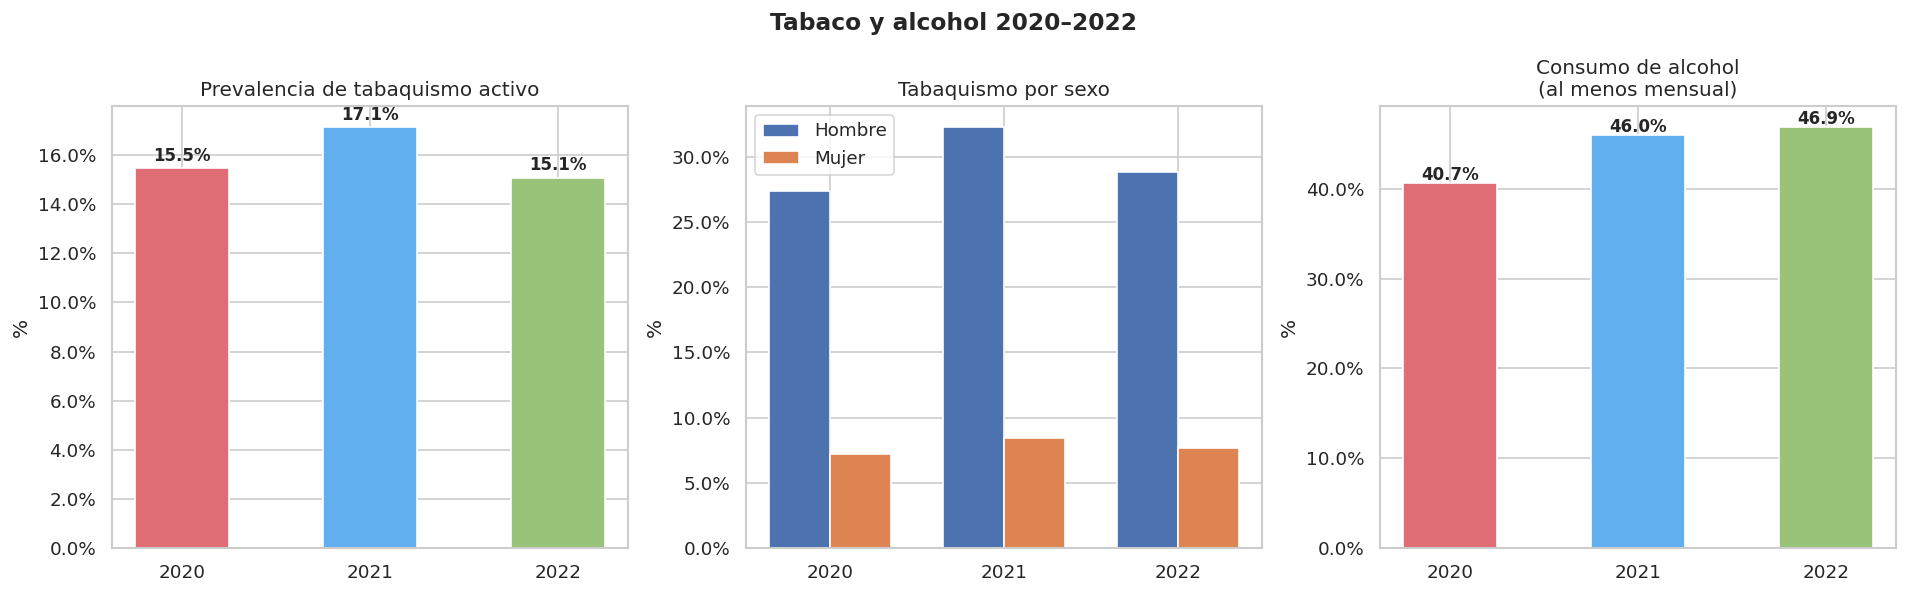

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Tabaco y alcohol 2020–2022', fontsize=14, fontweight='bold')

# 3.1 % que fuma por año
ax = axes[0]
fuma_yr = {yr: df['fuma'].mean()*100 for yr, df in [('2020',df20),('2021',df21),('2022',df22)]}
bars = ax.bar(fuma_yr.keys(), fuma_yr.values(),
              color=[COLORS[y] for y in fuma_yr], edgecolor='white', width=0.5)
ax.set_title('Prevalencia de tabaquismo activo')
ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, fuma_yr.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 3.2 % que fuma por año y sexo
ax = axes[1]
x = np.arange(3)
w = 0.35
for i, (sexo, lbl, color) in enumerate([(1,'Hombre','#4C72B0'),(2,'Mujer','#DD8452')]):
    vals = []
    for yr, df in [('2020',df20),('2021',df21),('2022',df22)]:
        sub = df[df['sexo']==sexo]
        vals.append(sub['fuma'].mean()*100)
    ax.bar(x + (i-0.5)*w, vals, w, label=lbl, color=color, edgecolor='white')
ax.set_title('Tabaquismo por sexo')
ax.set_xticks(x); ax.set_xticklabels(YEARS)
ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

# 3.3 % consume alcohol por año
ax = axes[2]
alc_yr = {yr: df['consume_alcohol'].mean()*100
          for yr, df in [('2020',df20),('2021',df21),('2022',df22)]}
bars = ax.bar(alc_yr.keys(), alc_yr.values(),
              color=[COLORS[y] for y in alc_yr], edgecolor='white', width=0.5)
ax.set_title('Consumo de alcohol\n(al menos mensual)')
ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, alc_yr.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/tabaco_alcohol_tendencia.png', bbox_inches='tight')
plt.show()

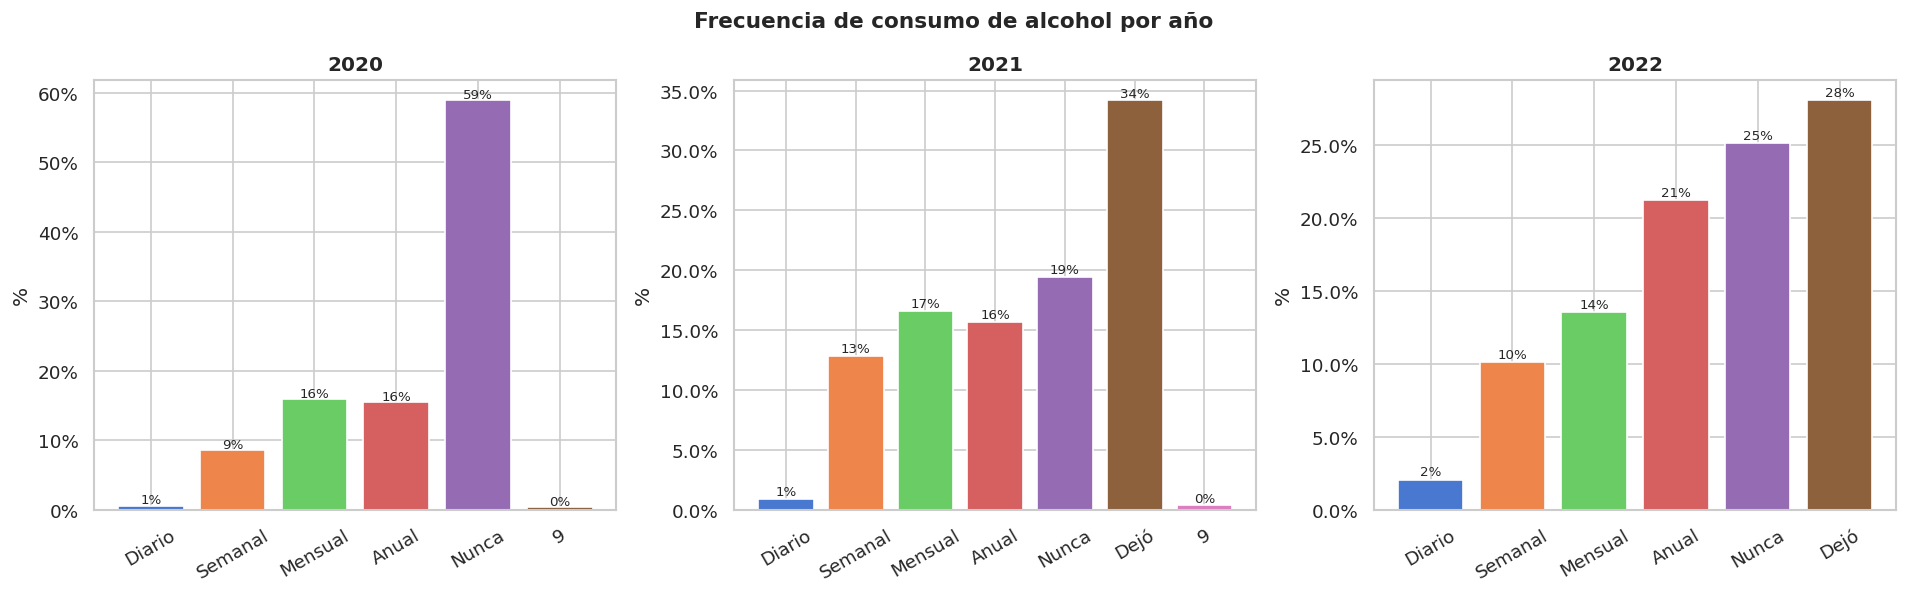

In [8]:
# Frecuencia de alcohol desglosada por año
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Frecuencia de consumo de alcohol por año', fontsize=13, fontweight='bold')

alc_labels = {1:'Diario', 2:'Semanal', 3:'Mensual', 4:'Anual', 5:'Nunca', 6:'Dejó'}
for ax, (yr, df) in zip(axes, [('2020',df20),('2021',df21),('2022',df22)]):
    counts = df['alcohol_frecuencia'].value_counts().sort_index()
    counts.index = [alc_labels.get(int(i), str(i)) for i in counts.index]
    pct = counts / counts.sum() * 100
    bars = ax.bar(counts.index, pct.values,
                  color=sns.color_palette('muted', len(counts)), edgecolor='white')
    ax.set_title(yr, fontsize=12, fontweight='bold')
    ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, pct.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.0f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/alcohol_frecuencia.png', bbox_inches='tight')
plt.show()

---
## 4. Salud mental y seguridad

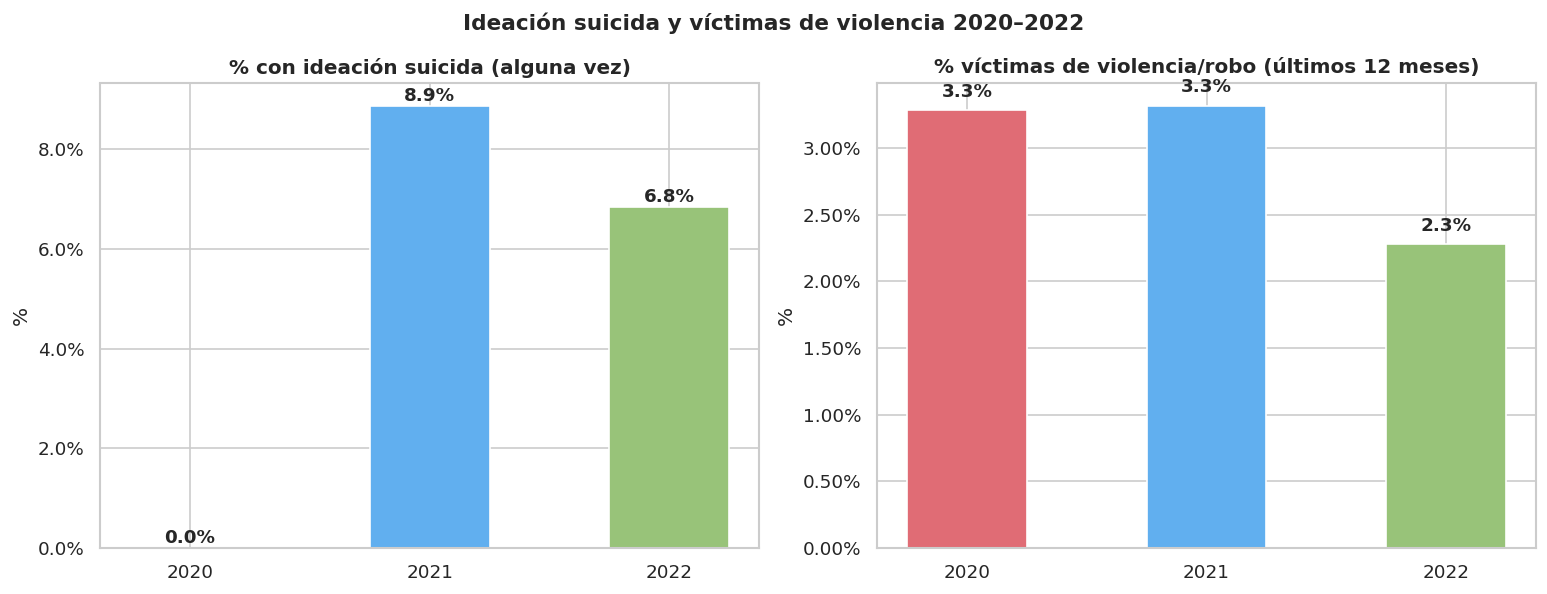

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ideación suicida y víctimas de violencia 2020–2022',
             fontsize=13, fontweight='bold')

metrics = [
    (axes[0], 'ideacion_suicida', '% con ideación suicida (alguna vez)'),
    (axes[1], 'victima_violencia', '% víctimas de violencia/robo (últimos 12 meses)'),
]

for ax, col, title in metrics:
    vals = {yr: df[col].mean()*100 for yr, df in [('2020',df20),('2021',df21),('2022',df22)]}
    bars = ax.bar(vals.keys(), vals.values(),
                  color=[COLORS[y] for y in vals], edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, vals.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/salud_mental_seguridad.png', bbox_inches='tight')
plt.show()

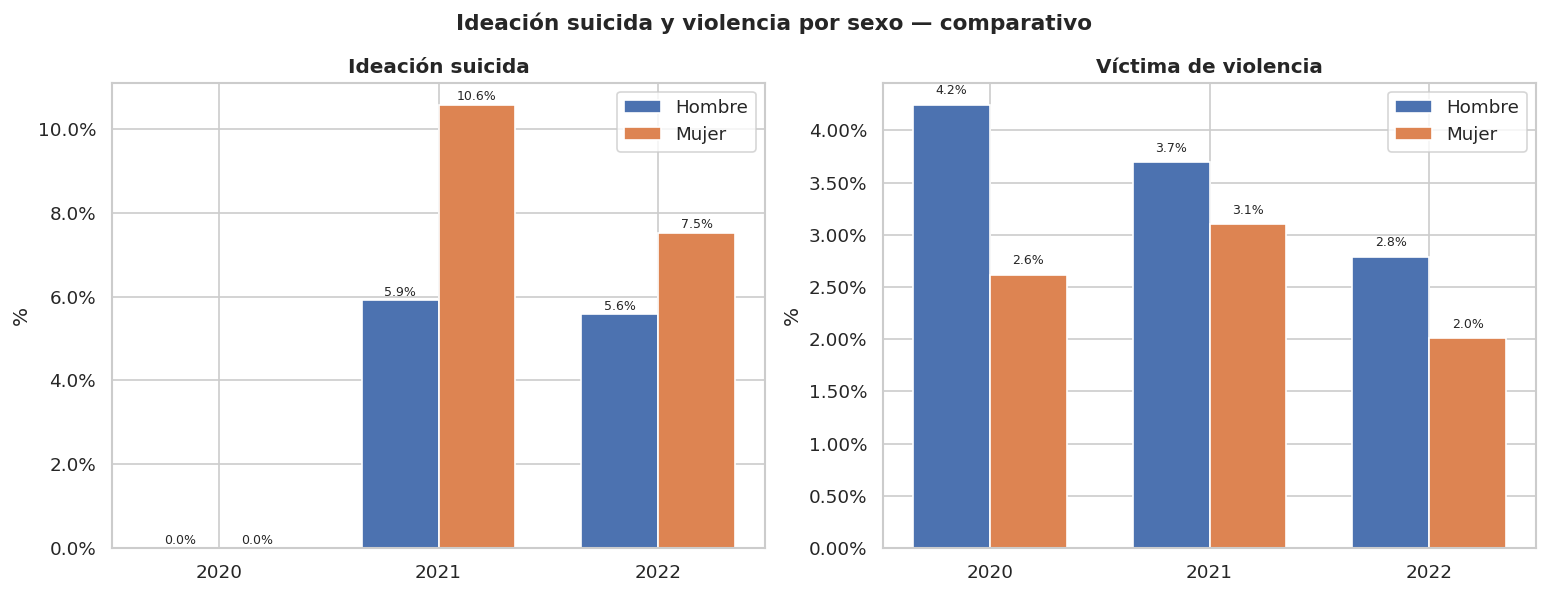

In [10]:
# Ideación suicida por sexo y año
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ideación suicida y violencia por sexo — comparativo', fontsize=13, fontweight='bold')

for ax, col, title in [(axes[0],'ideacion_suicida','Ideación suicida'),
                        (axes[1],'victima_violencia','Víctima de violencia')]:
    x = np.arange(3); w = 0.35
    for i, (sexo, lbl, color) in enumerate([(1,'Hombre','#4C72B0'),(2,'Mujer','#DD8452')]):
        vals = [df[df['sexo']==sexo][col].mean()*100
                for df in [df20, df21, df22]]
        bars = ax.bar(x+(i-0.5)*w, vals, w, label=lbl, color=color, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                    f'{val:.1f}%', ha='center', fontsize=7.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(YEARS)
    ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/salud_mental_sexo.png', bbox_inches='tight')
plt.show()

---
## 5. Enfermedades crónicas — 2021 vs 2022
> *La encuesta 2020 no incluyó preguntas de diagnóstico de enfermedades crónicas.*

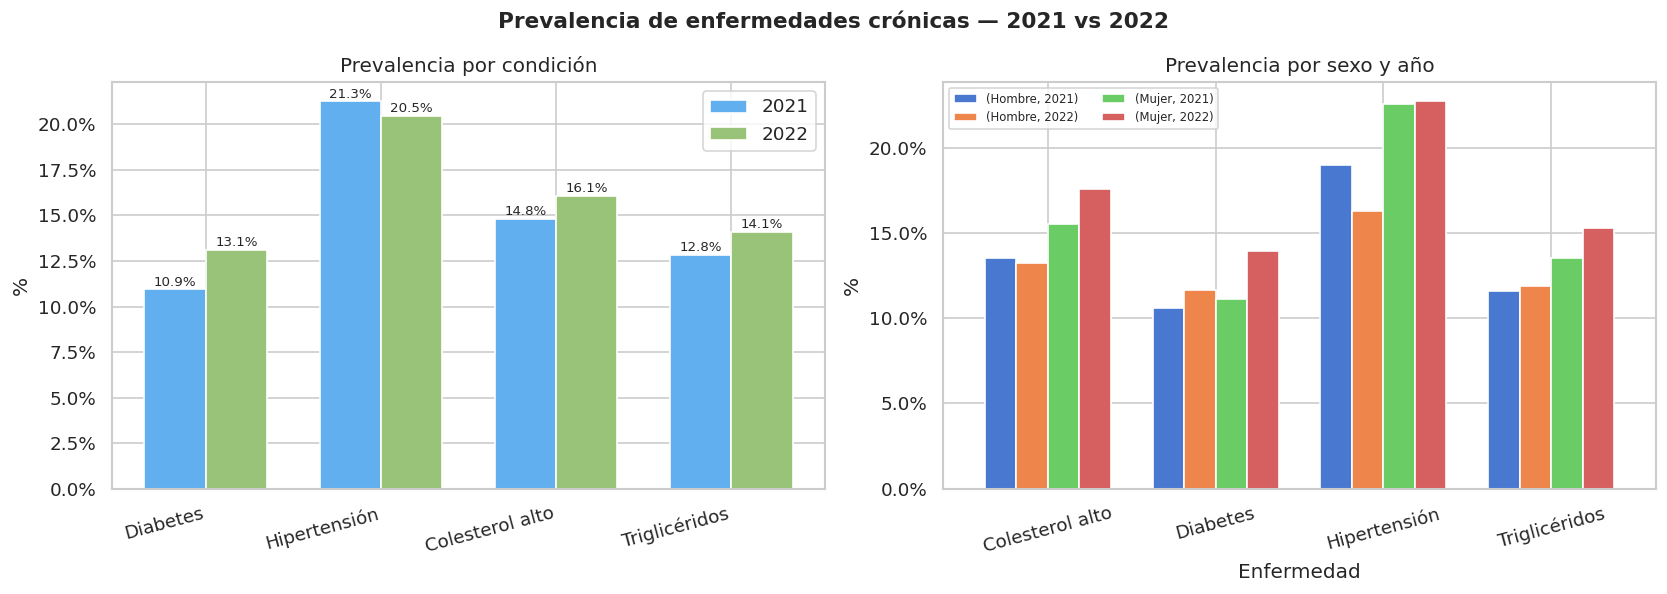

In [11]:
enf_map = {
    'Diabetes':         'diabetes',
    'Hipertensión':     'hipertension',
    'Colesterol alto':  'colesterol',
    'Triglicéridos':    'trigliceridos',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prevalencia de enfermedades crónicas — 2021 vs 2022', fontsize=13, fontweight='bold')

# 5.1 Barras agrupadas por enfermedad
ax = axes[0]
enf_labels = list(enf_map.keys())
vals21 = [df21[col].mean()*100 for col in enf_map.values()]
vals22 = [df22[col].mean()*100 for col in enf_map.values()]

x = np.arange(len(enf_labels)); w = 0.35
b1 = ax.bar(x-w/2, vals21, w, label='2021', color=COLORS['2021'], edgecolor='white')
b2 = ax.bar(x+w/2, vals22, w, label='2022', color=COLORS['2022'], edgecolor='white')
ax.set_title('Prevalencia por condición')
ax.set_xticks(x); ax.set_xticklabels(enf_labels, rotation=15, ha='right')
ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
for bar, val in list(zip(b1,vals21)) + list(zip(b2,vals22)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', fontsize=8)

# 5.2 Por sexo (2021 vs 2022 stacked)
ax = axes[1]
rows = []
for yr, df in [('2021',df21),('2022',df22)]:
    for enf, col in enf_map.items():
        for sexo, lbl in [(1,'Hombre'),(2,'Mujer')]:
            sub = df[df['sexo']==sexo]
            rows.append({'Año':yr,'Enfermedad':enf,'Sexo':lbl,'Prev':sub[col].mean()*100})
heat_df = pd.DataFrame(rows)
pivot = heat_df.pivot_table(index='Enfermedad', columns=['Sexo','Año'], values='Prev')
pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.75)
ax.set_title('Prevalencia por sexo y año')
ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/enfermedades_cronicas.png', bbox_inches='tight')
plt.show()

---
## 6. Síntomas depresivos — 2021 vs 2022

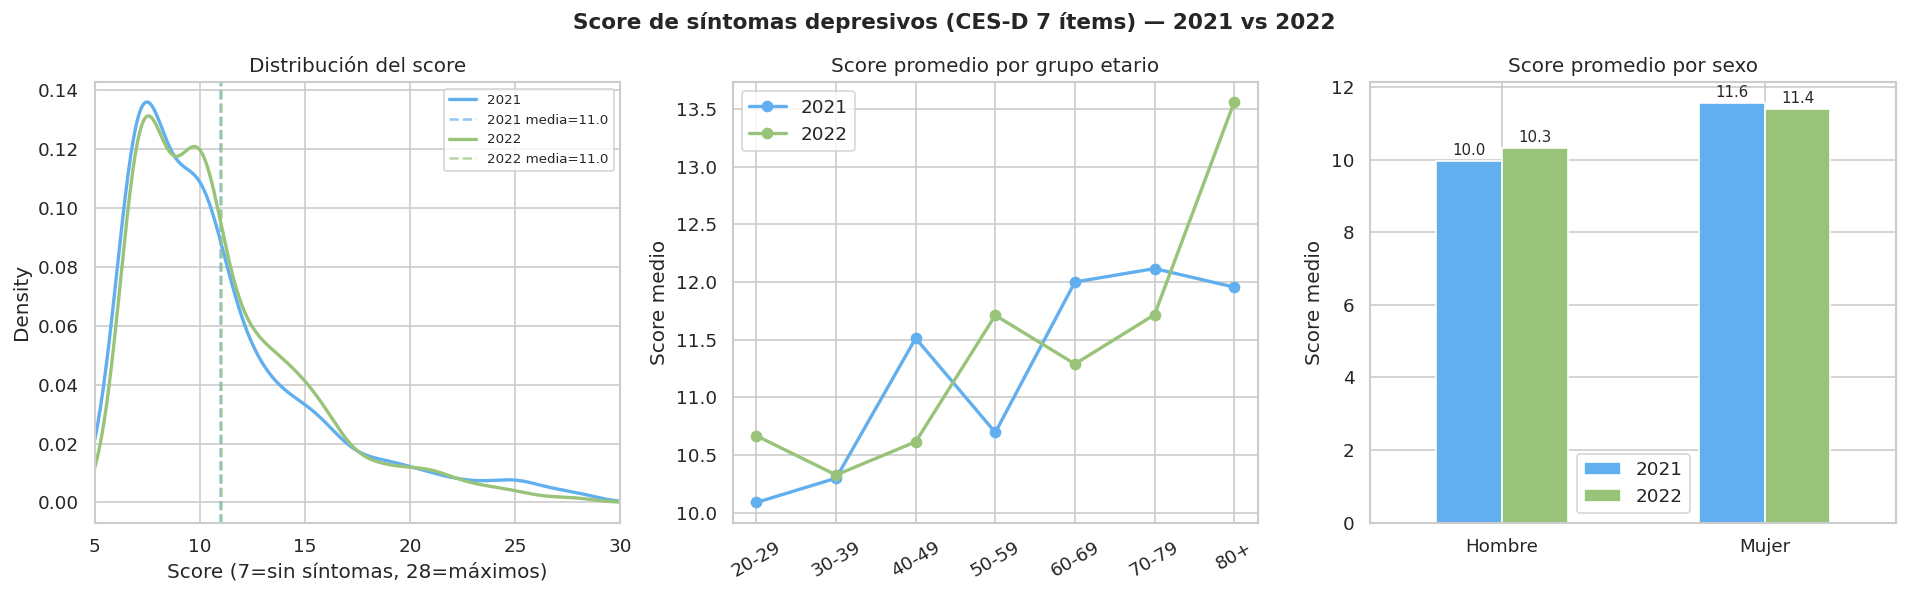

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Score de síntomas depresivos (CES-D 7 ítems) — 2021 vs 2022',
             fontsize=13, fontweight='bold')

# 6.1 Distribuciones superpuestas
ax = axes[0]
for yr, df, color in [('2021',df21,COLORS['2021']),('2022',df22,COLORS['2022'])]:
    df['score_dep'].plot.kde(ax=ax, label=yr, color=color, linewidth=2)
    ax.axvline(df['score_dep'].mean(), color=color, linestyle='--', alpha=0.7,
               label=f'{yr} media={df["score_dep"].mean():.1f}')
ax.set_title('Distribución del score')
ax.set_xlabel('Score (7=sin síntomas, 28=máximos)')
ax.legend(fontsize=8); ax.set_xlim(5, 30)

# 6.2 Score promedio por grupo etario
ax = axes[1]
for yr, df, color in [('2021',df21,COLORS['2021']),('2022',df22,COLORS['2022'])]:
    means = df.groupby('Grupo etario', observed=True)['score_dep'].mean()
    ax.plot(means.index.astype(str), means.values, marker='o',
            label=yr, color=color, linewidth=2, markersize=6)
ax.set_title('Score promedio por grupo etario')
ax.set_xlabel(''); ax.set_ylabel('Score medio')
ax.tick_params(axis='x', rotation=30)
ax.legend()

# 6.3 Score promedio por sexo y año
ax = axes[2]
dep_sex = []
for yr, df in [('2021',df21),('2022',df22)]:
    for sexo, lbl in [(1,'Hombre'),(2,'Mujer')]:
        dep_sex.append({'Año':yr,'Sexo':lbl,'Score':df[df['sexo']==sexo]['score_dep'].mean()})
dep_sex_df = pd.DataFrame(dep_sex)
pivot_dep = dep_sex_df.pivot(index='Sexo', columns='Año', values='Score')
pivot_dep.plot(kind='bar', ax=ax, color=[COLORS['2021'],COLORS['2022']],
               edgecolor='white', width=0.5)
ax.set_title('Score promedio por sexo')
ax.set_ylabel('Score medio'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/score_depresion.png', bbox_inches='tight')
plt.show()

---
## 7. Dificultades funcionales — 2021 vs 2022

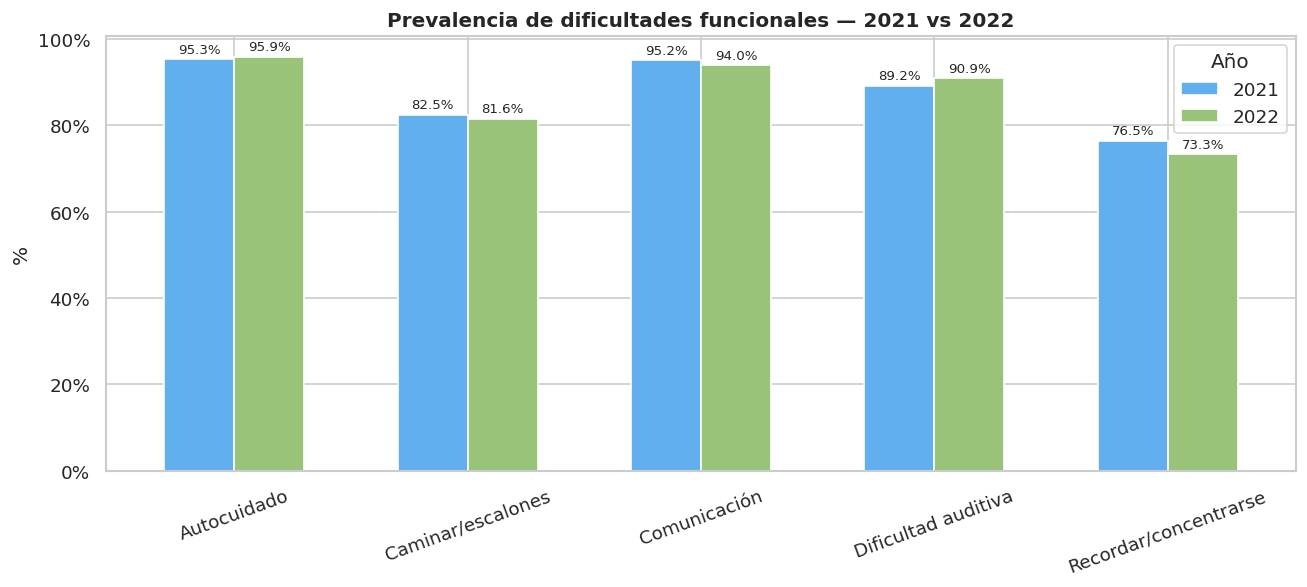

In [13]:
dif_map = {
    'Dificultad auditiva':      'A1404B ¿Tiene dificultades para oír?',
    'Caminar/escalones':        'A1405 ¿Tiene dificultad para caminar o subir escalones?',
    'Recordar/concentrarse':    'A1406 ¿Tiene dificultad para recordar o concentrarse?',
    'Autocuidado':              [c for c in df21.columns if 'A1407' in c][0],
    'Comunicación':             [c for c in df21.columns if 'A1408' in c][0],
}

rows_dif = []
for label, col in dif_map.items():
    for yr, df in [('2021',df21),('2022',df22)]:
        col_match = col if col in df.columns else next((c for c in df.columns if col[:10] in c), None)
        if col_match is None: continue
        valid = df[col_match].isin([1,2,3])
        pct = df.loc[valid, col_match].isin([1,3]).mean() * 100
        rows_dif.append({'Dificultad':label,'Año':yr,'%':pct})

dif_df = pd.DataFrame(rows_dif)
pivot_dif = dif_df.pivot(index='Dificultad', columns='Año', values='%')

fig, ax = plt.subplots(figsize=(11, 5))
pivot_dif.plot(kind='bar', ax=ax, color=[COLORS['2021'],COLORS['2022']],
               edgecolor='white', width=0.6)
ax.set_title('Prevalencia de dificultades funcionales — 2021 vs 2022', fontweight='bold')
ax.set_ylabel('%'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
ax.legend(title='Año')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/comparativo/discapacidades.png', bbox_inches='tight')
plt.show()

---
## 8. Dataset panel armonizado

Se construye un dataset unificado con las variables disponibles en los **tres años**.

In [14]:
common_cols = ['año','edad','sexo','sexo_lbl','Grupo etario','Urbanidad','Municipio',
               'fuma','consume_alcohol','alcohol_frecuencia',
               'ideacion_suicida','victima_violencia']

panel = pd.concat([
    df20[common_cols],
    df21[common_cols],
    df22[common_cols],
], ignore_index=True)

print(f'Panel 3 años: {panel.shape}')
print(panel.groupby('año').size().rename('n').to_frame().T.to_string())
panel.head()

Panel 3 años: (3377, 12)
año  2020  2021  2022
n    1035  1115  1227


,año,edad,sexo,sexo_lbl,Grupo etario,Urbanidad,Municipio,fuma,consume_alcohol,alcohol_frecuencia,ideacion_suicida,victima_violencia
0,2020,58,2,Mujer,50-59,Rural,ABASOLO,0,0,5,0,0
1,2020,30,2,Mujer,30-39,Rural,ABASOLO,0,1,4,0,0
2,2020,28,2,Mujer,20-29,Rural,ABASOLO,0,0,5,0,0
3,2020,55,2,Mujer,50-59,Rural,ABASOLO,0,0,5,0,0
4,2020,81,1,Hombre,80+,Rural,ABASOLO,0,0,5,0,0


In [15]:
# Guardar panel
panel.to_csv('../data/processed/ensadul_GTO_panel_3yr.csv', index=False, encoding='utf-8-sig')

# Panel extendido solo 2021–2022
ext_cols = common_cols + ['diabetes','hipertension','colesterol','trigliceridos','score_dep']
panel_ext = pd.concat([
    df21[[c for c in ext_cols if c in df21.columns]],
    df22[[c for c in ext_cols if c in df22.columns]],
], ignore_index=True)
panel_ext.to_csv('../data/processed/ensadul_GTO_panel_2yr.csv', index=False, encoding='utf-8-sig')

print(f'Panel 3 años exportado → ensadul_GTO_panel_3yr.csv  ({panel.shape})')
print(f'Panel 2 años exportado → ensadul_GTO_panel_2yr.csv  ({panel_ext.shape})')

Panel 3 años exportado → ensadul_GTO_panel_3yr.csv  ((3377, 12))
Panel 2 años exportado → ensadul_GTO_panel_2yr.csv  ((2342, 17))


---
## 9. Resumen de hallazgos

In [16]:
print('=' * 70)
print('RESUMEN — ANÁLISIS COMPARATIVO ENSADUL/ENSANUT GTO 2020–2022')
print('=' * 70)

print('\n── Muestra ──────────────────────────────────────────────')
for yr, df in [('2020',df20),('2021',df21),('2022',df22)]:
    print(f'  {yr}: {len(df):,} personas | edad media {df["edad"].mean():.1f} años')

print('\n── Tabaquismo (% fuma actualmente) ──────────────────────')
for yr, df in [('2020',df20),('2021',df21),('2022',df22)]:
    total = df['fuma'].mean()*100
    h = df[df['sexo']==1]['fuma'].mean()*100
    m = df[df['sexo']==2]['fuma'].mean()*100
    print(f'  {yr}: {total:.1f}%  (H: {h:.1f}% | M: {m:.1f}%)')

print('\n── Consumo de alcohol (al menos mensual) ────────────────')
for yr, df in [('2020',df20),('2021',df21),('2022',df22)]:
    print(f'  {yr}: {df["consume_alcohol"].mean()*100:.1f}%')

print('\n── Ideación suicida (alguna vez) ────────────────────────')
for yr, df in [('2020',df20),('2021',df21),('2022',df22)]:
    h = df[df['sexo']==1]['ideacion_suicida'].mean()*100
    m = df[df['sexo']==2]['ideacion_suicida'].mean()*100
    print(f'  {yr}: {df["ideacion_suicida"].mean()*100:.1f}%  (H: {h:.1f}% | M: {m:.1f}%)')

print('\n── Víctimas de violencia/robo (12 meses) ────────────────')
for yr, df in [('2020',df20),('2021',df21),('2022',df22)]:
    print(f'  {yr}: {df["victima_violencia"].mean()*100:.1f}%')

print('\n── Enfermedades crónicas (2021 vs 2022) ─────────────────')
for enf, col in [('Diabetes','diabetes'),('Hipertensión','hipertension'),
                  ('Colesterol','colesterol'),('Triglicéridos','trigliceridos')]:
    p21 = df21[col].mean()*100
    p22 = df22[col].mean()*100
    delta = p22 - p21
    arrow = '▲' if delta > 0 else '▼'
    print(f'  {enf:<14}  2021: {p21:.1f}%  →  2022: {p22:.1f}%  {arrow}{abs(delta):.1f} pp')

print('\n── Score depresión CES-D (2021 vs 2022) ─────────────────')
print(f'  2021: media={df21["score_dep"].mean():.2f}  DE={df21["score_dep"].std():.2f}')
print(f'  2022: media={df22["score_dep"].mean():.2f}  DE={df22["score_dep"].std():.2f}')
print('=' * 70)

RESUMEN — ANÁLISIS COMPARATIVO ENSADUL/ENSANUT GTO 2020–2022

── Muestra ──────────────────────────────────────────────
  2020: 1,035 personas | edad media 45.8 años
  2021: 1,115 personas | edad media 46.2 años
  2022: 1,227 personas | edad media 46.5 años

── Tabaquismo (% fuma actualmente) ──────────────────────
  2020: 15.5%  (H: 27.4% | M: 7.2%)
  2021: 17.1%  (H: 32.3% | M: 8.5%)
  2022: 15.1%  (H: 28.8% | M: 7.7%)

── Consumo de alcohol (al menos mensual) ────────────────
  2020: 40.7%
  2021: 46.0%
  2022: 46.9%

── Ideación suicida (alguna vez) ────────────────────────
  2020: 0.0%  (H: 0.0% | M: 0.0%)
  2021: 8.9%  (H: 5.9% | M: 10.6%)
  2022: 6.8%  (H: 5.6% | M: 7.5%)

── Víctimas de violencia/robo (12 meses) ────────────────
  2020: 3.3%
  2021: 3.3%
  2022: 2.3%

── Enfermedades crónicas (2021 vs 2022) ─────────────────
  Diabetes        2021: 10.9%  →  2022: 13.1%  ▲2.2 pp
  Hipertensión    2021: 21.3%  →  2022: 20.5%  ▼0.8 pp
  Colesterol      2021: 14.8%  →  2022: 16.1%